In [5]:
# ============================================================
# Credit Card Fraud Detection Using Machine Learning
# Author: Vibhashree GM
# ============================================================

# 1. Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")


# ============================================================
# 2. Load dataset
# ============================================================

# Download creditcard.csv from Kaggle and place it in the same folder as this notebook

df = pd.read_csv("/content/creditcard.csv")

print("Dataset shape:", df.shape)
print(df.head())


# ============================================================
# 3. Basic data understanding
# ============================================================

print("\nDataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df["Class"].value_counts())

print("\nClass distribution in percentage:")
print(df["Class"].value_counts(normalize=True) * 100)




Dataset shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

    

In [7]:
import os

os.makedirs("visuals", exist_ok=True)

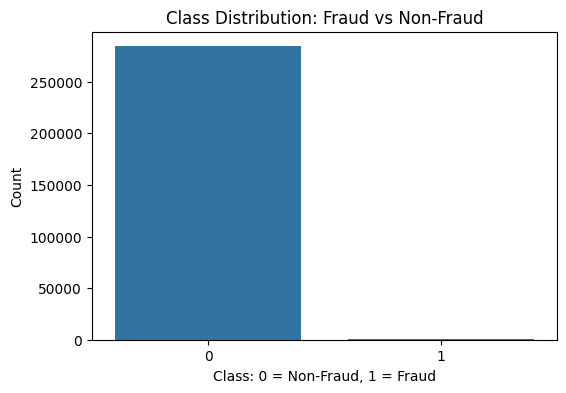

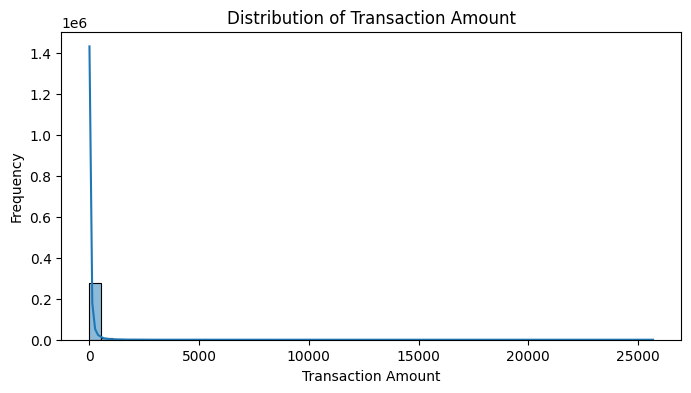

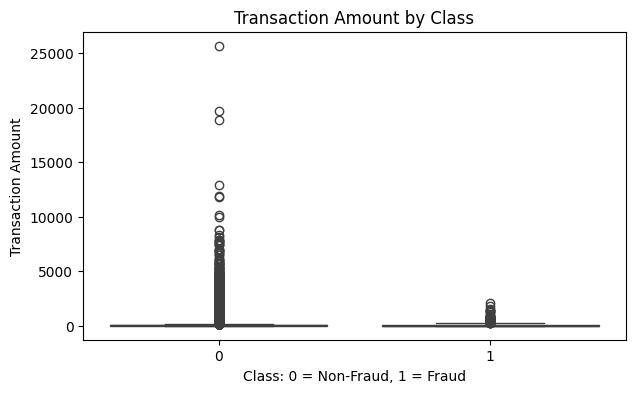

In [8]:
# ============================================================
# 4. Exploratory Data Analysis
# ============================================================

# Class distribution chart


import os
os.makedirs("visuals", exist_ok=True)

plt.figure(figsize=(6, 4))
sns.countplot(x="Class", data=df)
plt.title("Class Distribution: Fraud vs Non-Fraud")
plt.xlabel("Class: 0 = Non-Fraud, 1 = Fraud")
plt.ylabel("Count")

plt.savefig("visuals/class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


# Amount distribution


plt.figure(figsize=(8, 4))
sns.histplot(df["Amount"], bins=50, kde=True)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.savefig("visuals/transaction_amount_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# Fraud vs non-fraud amount comparison


plt.figure(figsize=(7, 4))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Transaction Amount by Class")
plt.xlabel("Class: 0 = Non-Fraud, 1 = Fraud")
plt.ylabel("Transaction Amount")

plt.savefig("visuals/amount_by_class.png", dpi=300, bbox_inches="tight")
plt.show()



In [6]:
# Correlation with target variable

correlation = df.corr()["Class"].sort_values(ascending=False)
print("\nCorrelation with Class:")
print(correlation)



Correlation with Class:
Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


In [2]:

# ============================================================
# 5. Feature scaling
# ============================================================

# Time and Amount are not PCA-transformed, so we scale them

scaler = StandardScaler()

df["scaled_amount"] = scaler.fit_transform(df[["Amount"]])
df["scaled_time"] = scaler.fit_transform(df[["Time"]])

# Drop original Time and Amount columns

df = df.drop(["Time", "Amount"], axis=1)

print("\nData after scaling:")
print(df.head())


# ============================================================
# 6. Define independent and dependent variables
# ============================================================

X = df.drop("Class", axis=1)
y = df["Class"]


# ============================================================
# 7. Train-test split
# ============================================================

# Important: split before SMOTE to avoid data leakage

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining class distribution before SMOTE:")
print(y_train.value_counts())


# ============================================================
# 8. Handle class imbalance using SMOTE
# ============================================================

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nTraining class distribution after SMOTE:")
print(y_train_smote.value_counts())


# ============================================================
# 9. Train Logistic Regression model
# ============================================================

log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train_smote, y_train_smote)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]


# ============================================================
# 10. Train Random Forest model
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]


# ============================================================
# 11. Model evaluation function
# ============================================================

def evaluate_model(model_name, y_test, y_pred, y_prob):
    print("\n===================================================")
    print(model_name)
    print("===================================================")

    print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred), 4))
    print("Recall:", round(recall_score(y_test, y_pred), 4))
    print("F1-score:", round(f1_score(y_test, y_pred), 4))
    print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


evaluate_model("Logistic Regression with SMOTE", y_test, y_pred_log, y_prob_log)
evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf)


# ============================================================
# 12. Compare models in one table
# ============================================================

model_results = pd.DataFrame({
    "Model": ["Logistic Regression with SMOTE", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "F1_Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

print("\nModel Comparison:")
print(model_results)



Data after scaling:
         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10  ...       V22       V23       V24       V25  \
0  0.098698  0.363787  0.090794  ...  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425 -0.166974  ... -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  0.207643  ...  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024 -0.054952  ...  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  0.753074  ...  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28  Class  scaled_

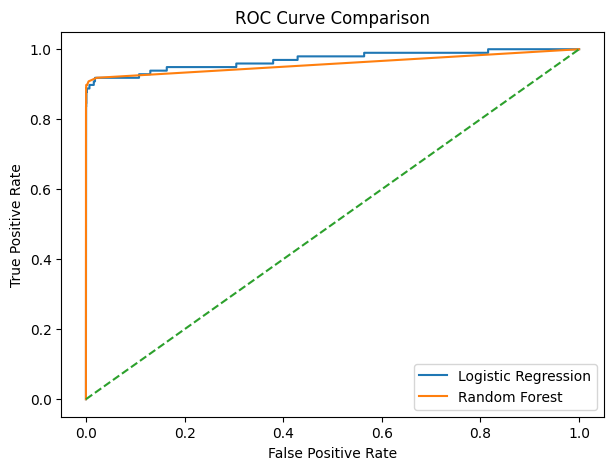

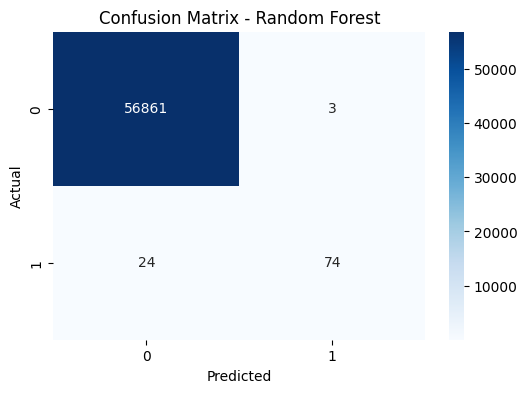


Top 10 Important Features:
   Feature  Importance
13     V14    0.209889
9      V10    0.117423
3       V4    0.114414
16     V17    0.087311
11     V12    0.072560
10     V11    0.071794
2       V3    0.068853
15     V16    0.037365
6       V7    0.031200
1       V2    0.025360


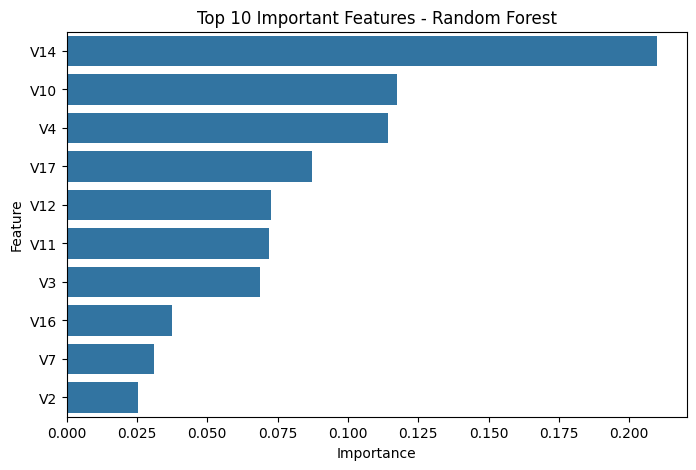

In [9]:


# ============================================================
# 13. ROC Curve
# ============================================================


fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(7, 5))
plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.savefig("visuals/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 14. Confusion Matrix for best model
# ============================================================

# You can change this depending on which model performs better

best_model_name = "Random Forest"
best_y_pred = y_pred_rf


cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("visuals/confusion_matrix_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 15. Feature importance for Random Forest
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 10 Important Features:")
print(feature_importance.head(10))


plt.figure(figsize=(8, 5))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)
plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.savefig("visuals/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()



In [4]:

# ============================================================
# 16. Save model results
# ============================================================

model_results.to_csv("model_comparison_results.csv", index=False)
feature_importance.to_csv("feature_importance.csv", index=False)

print("\nFiles saved successfully:")
print("model_comparison_results.csv")
print("feature_importance.csv")


Files saved successfully:
model_comparison_results.csv
feature_importance.csv
